# Chapter 4 — Trees and forests are kernels

*Companion notebook to **The Learned Kernel**, Ch. 4. Run top to bottom.*

A fitted gradient-boosted forest **is** a kernel machine — exactly. Read it as a
generalized Nadaraya–Watson (GNW) operator with three separable parts: an **input
geometry** (the leaf kernel), a **value representation**, and a **decoder**. Use the
forest's own **leaf scores** as the values and you recover its predictions to machine
precision; use raw labels and you get a crude smoother; use ridge-refit values and you
get kernel ridge. This notebook shows all of that on the running data.

The construction is library-agnostic — XGBoost, LightGBM, CatBoost and scikit-learn's
GradientBoosting all expose per-tree leaf indices and leaf scores via a forward pass. We
use scikit-learn's here so nothing extra needs installing.

**The frame** — *what is learned · how scored · what you read off.* The forest learns the
leaf geometry (supervised partition) **and** the value table (leaf scores). Correction is
scored out-of-fold (Ch. 3's leakage discipline). You read off the leaf-mates behind each
prediction.

## Setup

In [1]:
# On Google Colab (or any fresh env) install the companion package; no-op locally.
try:
    import lkbook  # noqa: F401
except ModuleNotFoundError:
    import subprocess, sys
    subprocess.run([sys.executable, "-m", "pip", "install", "-q",
        "learned-kernel[notebooks] @ git+https://github.com/asudjianto-xml/Learned-Kernel.git"],
        check=True)

In [2]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from lkbook import load_california, set_style
from lkbook.chapters import ch04

set_style()
cal = load_california()
model, Xtr, ytr = ch04.fit_forest(cal)          # 200-tree gradient-boosted forest
lk = ch04.LeafKernel().fit(model)
print(f"forest: {len(model.estimators_)} trees; leaf feature dimension Σ m_t = {lk.n_cols}")

forest: 200 trees; leaf feature dimension Σ m_t = 1534


## 4.1  The leaf kernel

Two points are similar to the degree they share leaves: k(x,x') = (1/T) Σ_t 1{same leaf}
= (1/T) Ψ(x)ᵀΨ(x'). It is a Gram matrix (PSD), unit-diagonal, and valued in [0,1].

In [3]:
K = lk.gram(Xtr[:400], Xtr[:400])
print(f"diagonal mean      = {np.diag(K).mean():.3f}  (unit ⟹ Ch.3 convention)")
print(f"range              = [{K.min():.3f}, {K.max():.3f}]")
print(f"min eigenvalue     = {np.linalg.eigvalsh(K).min():.2e}  (≥ 0 ⟹ PSD)")

diagonal mean      = 1.000  (unit ⟹ Ch.3 convention)
range              = [0.110, 1.000]
min eigenvalue     = 1.41e-04  (≥ 0 ⟹ PSD)


## 4.2  The forest IS a kernel machine — exact GNW recovery

Read each tree as a one-hot Nadaraya–Watson operator over its leaves: the query's leaf
gets all the weight, returning that leaf's score γ_{t,ℓ}. Sum over trees and you recover
f(x) = f₀ + Σ_t η_t γ_{t,ℓ_t(x)} — the forest, **exactly**.

In [4]:
recon = ch04.gbdt_leaf_value_prediction(model, cal.Xte)   # GNW over leaf-score values
forest = model.predict(cal.Xte)
print(f"max |GNW reconstruction − forest.predict| = {np.max(np.abs(recon - forest)):.2e}")
assert np.max(np.abs(recon - forest)) < 1e-9              # exact, to machine precision
print("→ the fitted forest is exactly a generalized Nadaraya–Watson kernel machine.")

max |GNW reconstruction − forest.predict| = 0.00e+00
→ the fitted forest is exactly a generalized Nadaraya–Watson kernel machine.


## 4.3  The value axis is where the accuracy lives

One geometry, three value representations. Raw labels are crude; leaf scores are exact;
ridge-refit values are competitive. (Plus an out-of-fold residual layer — Ch. 3 honesty.)

In [5]:
vm = ch04.value_mechanisms(cal)
enh = ch04.residual_enhancement(cal)
tbl = pd.DataFrame({"test RMSE ($100k)": {
    "raw-label NW": round(vm["rawlabel_nw_rmse"], 3),
    "gradient-boosted forest": round(vm["forest_rmse"], 3),
    "leaf scores (exact GNW)": round(vm["exact_rmse"], 3),
    "ridge values (leaf KRR)": round(vm["ridge_rmse"], 3),
    "residual-enhanced (OOF)": round(enh["enhanced_rmse"], 3),
}})
print(f"residual enhancement: γ*={enh['gamma']:.2f}, "
      f"{enh['raw_rmse']:.3f} → {enh['enhanced_rmse']:.3f} (out-of-fold residuals)")
tbl

residual enhancement: γ*=0.25, 0.530 → 0.523 (out-of-fold residuals)


,test RMSE ($100k)
raw-label NW,1.088
gradient-boosted forest,0.530
leaf scores (exact GNW),0.530
ridge values (leaf KRR),0.540
residual-enhanced (OOF),0.523


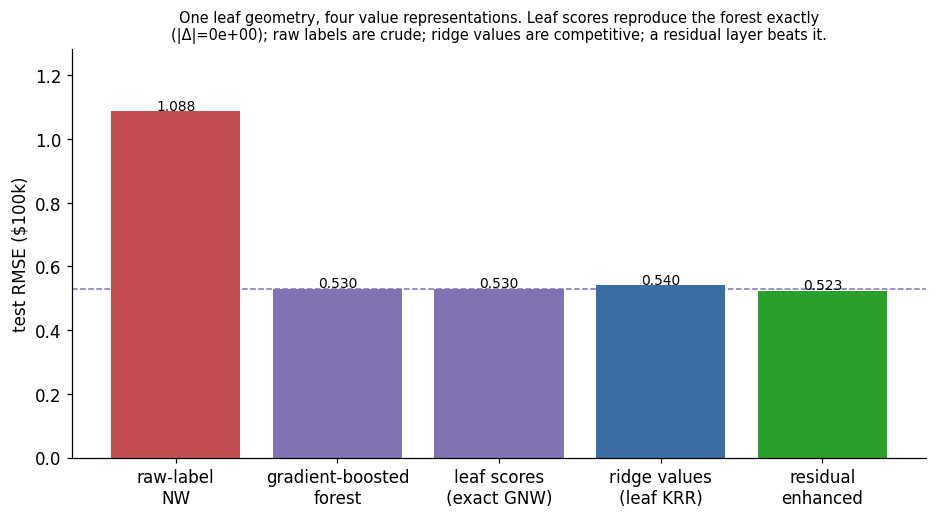

In [6]:
ch04.make_value_figure(cal)
plt.show()

Same geometry, same weights — only the values change. Reading the model as a kernel
machine costs no accuracy (the exact head *is* the model) and opens a design space the
forest never used.

## 4.4  Supervised geometry: data-adaptive vs chosen

The leaf kernel's similarity follows the *learned* partition; an RBF is an isotropic ball
the modeler picked. Move the query and compare.

In [7]:
from ipywidgets import interact, IntSlider

_idx = np.random.RandomState(0).choice(cal.n, ch04.N_TRAIN, replace=False)
_lon = cal.Xtr_raw[_idx, cal.col("Longitude")]
_lat = cal.Xtr_raw[_idx, cal.col("Latitude")]


def explore(q=7, ell=2.93, win=2.4):
    x = cal.Xte[q]
    k_leaf = lk.gram(x[None], Xtr)[0]
    k_rbf = np.exp(-((Xtr - x) ** 2).sum(1) / (2 * ell ** 2))
    qlon = cal.Xte_raw[q, cal.col("Longitude")]; qlat = cal.Xte_raw[q, cal.col("Latitude")]
    fig, axes = plt.subplots(1, 2, figsize=(12, 4.4), constrained_layout=True)
    for ax, (k, title) in zip(axes, [(k_leaf, "leaf kernel (learned)"),
                                     (k_rbf, "RBF (chosen)")]):
        m = k > 1e-6
        sc = ax.scatter(_lon[m], _lat[m], c=k[m], s=10, cmap="Reds", vmin=0, vmax=1)
        ax.scatter([qlon], [qlat], marker="*", s=220, c="yellow", edgecolors="k", zorder=5)
        ax.set_xlim(qlon - win, qlon + win); ax.set_ylim(qlat - win, qlat + win)
        ax.set_title(title); ax.set_xlabel("Longitude"); ax.set_ylabel("Latitude")
        fig.colorbar(sc, ax=ax, shrink=0.8)
    plt.show()


interact(explore, q=IntSlider(min=0, max=300, step=1, value=7, description="query"));

interactive(children=(IntSlider(value=7, description='query', max=300), FloatSlider(value=2.93, description='e…

## Exercises

Fill in each `# TODO`; the solution is one click away.

**(easy)** Confirm the leaf kernel's unit diagonal and [0,1] range, and that it is PSD.

In [8]:
# TODO: from K above, compute diagonal mean, min, max, and min eigenvalue
diag_mean = kmin = kmax = min_eig = None
print(diag_mean, kmin, kmax, min_eig)

None None None None


<details><summary>Solution</summary>

```python
diag_mean = float(np.diag(K).mean())     # 1.000
kmin, kmax = float(K.min()), float(K.max())
min_eig = float(np.linalg.eigvalsh(K).min())   # ≥ 0
print(diag_mean, kmin, kmax, min_eig)
```
Unit diagonal (each row of Ψ has exactly T ones), entries are fractions of trees in [0,1],
and K = ΨΨᵀ/T is a Gram matrix, hence PSD.
</details>

**(⋆)** Show the exact recovery is one-hot per tree: for one query, confirm each tree
contributes exactly its leaf's score. Pick the first test point and one tree, and check
that the tree's contribution equals its leaf value.

In [9]:
# TODO: for q=0 and tree t=0, compare LR*leaf_value vs the tree's own predict contribution
contrib = leaf_value_term = None

<details><summary>Solution</summary>

```python
x = cal.Xte[0:1]
t = 0; est = model.estimators_[0][0]
leaf = int(model.apply(x)[0, t])
leaf_value_term = ch04.LR * est.tree_.value.ravel()[leaf]
contrib = ch04.LR * est.predict(x)[0]      # the tree's own scaled contribution
print(leaf_value_term, contrib)            # equal: one-hot weight selects the leaf score
```
Each tree is a one-hot GNW operator: the query's leaf gets all the weight, so the tree's
contribution is exactly its leaf score. Summing the T contributions (plus f₀) is the forest.
</details>

---
*Companion to Chapter 4 of **The Learned Kernel**. The leaf kernel, the exact GNW recovery
and the value-axis comparison come from `lkbook.chapters.ch04` — the same code the book's
figures are generated from.*